In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from sklearn.model_selection import GridSearchCV,RepeatedStratifiedKFold,cross_validate
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import cohen_kappa_score
from src.model import logistic_regression
from src.model import random_forest
from src.untiles import classification_reports
from src.untiles import classification_evaluation_plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
X_train=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\X_train.csv')
X_test=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\X_test.csv')
y_test=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\y_test.csv')
y_train=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\y_train.csv')

In [4]:
y_test=y_test['SN']
y_train=y_train['SN']

In [5]:
X_train.head()

,Dec (J2000),SDSS,count,mag_info,mag_max,mag_mean,mag_median,mag_min,mag_std,magerr_max,magerr_mean,magerr_std,mjd_std,baseline,mag_baseline
0,44.16821,1,285,18.99,21.1823,19.597525,19.52700,18.7508,0.444157,0.551875,0.235378,0.068418,765.214916,2855.145077,2.4315
1,21.02971,1,18,16.67,21.0585,19.510139,20.22605,16.6727,1.580429,0.511079,0.283757,0.133324,611.416488,2319.689805,4.3858
2,6.96459,1,325,17.14,19.3370,18.386910,18.38320,17.6938,0.197263,0.390555,0.135795,0.022547,892.587073,2931.117294,1.6432
3,20.95205,1,312,14.53,19.5743,18.194120,18.27695,14.5148,0.778939,0.226632,0.133371,0.032267,909.917513,2955.956115,5.0595
4,34.21416,1,12,18.36,19.1883,18.412792,18.32870,17.8796,0.396659,0.194398,0.137355,0.027262,20.067393,45.919899,1.3087


In [6]:
X_test.head()

,Dec (J2000),SDSS,count,mag_info,mag_max,mag_mean,mag_median,mag_min,mag_std,magerr_max,magerr_mean,magerr_std,mjd_std,baseline,mag_baseline
0,-15.17508,0,17,19.30,20.9790,19.722271,19.70250,19.1117,0.519268,0.489025,0.248227,0.081922,450.025847,1880.819612,1.8673
1,22.73397,1,32,18.70,21.3660,19.315237,19.02265,17.8492,0.902925,0.616151,0.235108,0.125243,1072.556771,2821.306135,3.5168
2,9.00012,1,3,18.11,19.9373,18.502300,18.10700,17.4626,1.283835,0.271012,0.160898,0.096066,0.007824,0.015376,2.4747
3,-18.43059,0,4,20.23,20.2346,17.990800,18.60510,14.5184,2.442279,0.319080,0.230510,0.101283,1090.500424,2181.008746,5.7162
4,-9.00894,0,10,18.24,20.0194,18.740080,18.55720,18.2358,0.529069,0.266904,0.155118,0.042603,11.138110,35.829864,1.7836


In [7]:
y_test.head()

0    1
1    0
2    0
3    0
4    1
Name: SN, dtype: int64

In [8]:
y_train.head()

0    0
1    0
2    1
3    0
4    1
Name: SN, dtype: int64

In [9]:
print(y_test.shape)
print(y_train.shape)
print(X_train.shape)
print(X_test.shape)

(747,)
(2987,)
(2987, 15)
(747, 15)


In [10]:
search_space={'logistic_regression__C':[0.01,0.1,1,10,100]}
lr_grid=GridSearchCV(logistic_regression(),search_space,scoring='f1_macro',cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=0)).fit(X_train,y_train)

In [11]:
lr_train_preds=lr_grid.predict(X_train)
lr_train_preds_proba=lr_grid.predict_proba(X_train)[:,1]

In [12]:
classification_reports(y_train,lr_train_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.812099,0.722073,0.778373,0.767086,0.777167
recall,0.829869,0.697153,0.778373,0.763511,0.778373
f1-score,0.820887,0.709394,0.778373,0.765141,0.777626
support,1828.000000,1159.000000,0.778373,2987.000000,2987.000000


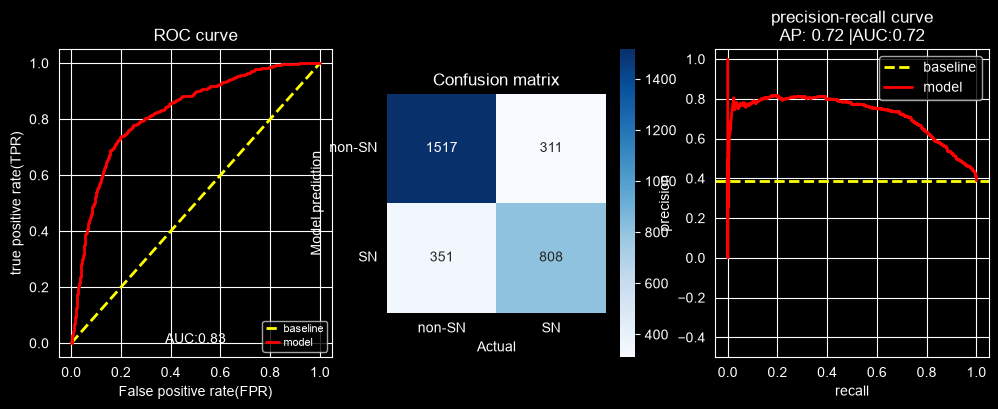

In [13]:
classification_evaluation_plots(y_train,lr_train_preds,lr_train_preds_proba)

In [14]:
lr_grid.best_params_

{'logistic_regression__C': 1}

In [15]:
lr_grid.best_score_

np.float64(0.7620608262095303)

In [16]:
lr_test_preds=lr_grid.predict(X_test)
lr_test_preds_proba=lr_grid.predict_proba(X_test)[:,1]

In [17]:
classification_reports(y_test,lr_test_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.823799,0.687097,0.767068,0.755448,0.770728
recall,0.787746,0.734483,0.767068,0.761114,0.767068
f1-score,0.805369,0.710000,0.767068,0.757685,0.768345
support,457.000000,290.000000,0.767068,747.000000,747.000000


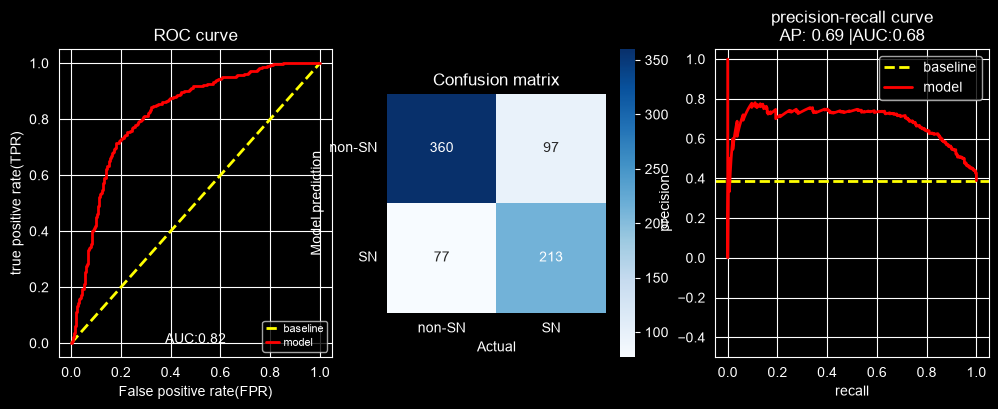

In [18]:
classification_evaluation_plots(y_test,lr_test_preds,lr_test_preds_proba)

In [19]:
pipeline=Pipeline([('polynomial',PolynomialFeatures(degree=2)),('scaler',StandardScaler()),('lr',LogisticRegression(max_iter=10000,random_state=0))])

In [20]:
fitted_lr=pipeline.fit(X_train,y_train)

In [21]:
lr_p_train_preds=fitted_lr.predict(X_train)
lr_p_train_preds_proba=fitted_lr.predict_proba(X_train)[:,1]


In [22]:
classification_reports(y_train,lr_p_train_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.833513,0.751547,0.802477,0.792530,0.801709
recall,0.846280,0.733391,0.802477,0.789835,0.802477
f1-score,0.839848,0.742358,0.802477,0.791103,0.802020
support,1828.000000,1159.000000,0.802477,2987.000000,2987.000000


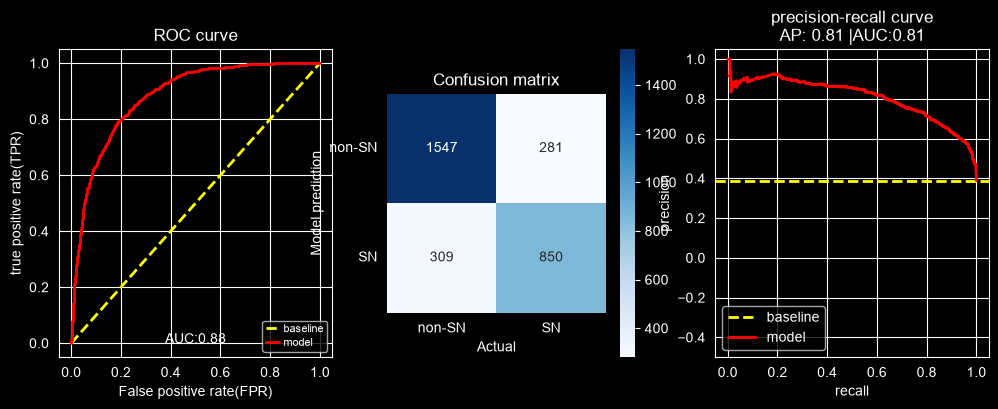

In [23]:
classification_evaluation_plots(y_train,lr_p_train_preds,lr_p_train_preds_proba)

In [24]:
lr_p_test_preds=fitted_lr.predict(X_test)
lr_p_test_preds_proba=fitted_lr.predict_proba(X_test)[:,1]

In [25]:
classification_reports(y_test,lr_p_test_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.831111,0.720539,0.787149,0.775825,0.788185
recall,0.818381,0.737931,0.787149,0.778156,0.787149
f1-score,0.824697,0.729131,0.787149,0.776914,0.787596
support,457.000000,290.000000,0.787149,747.000000,747.000000


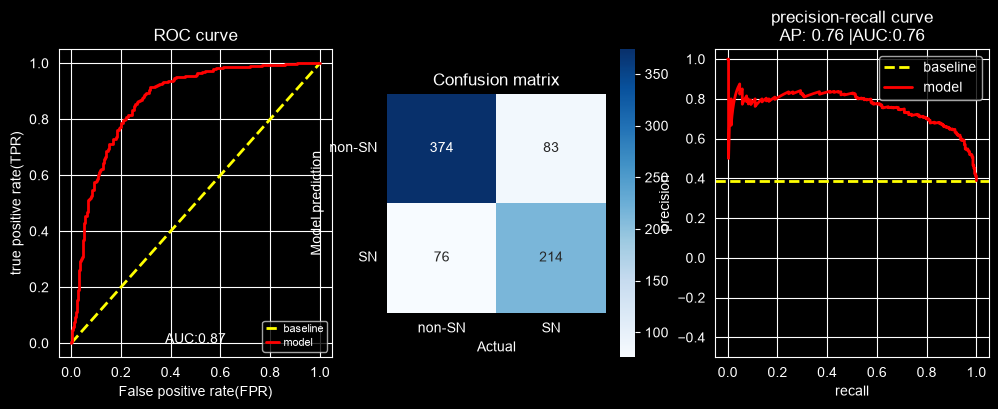

In [26]:
classification_evaluation_plots(y_test,lr_p_test_preds,lr_p_test_preds_proba)

In [27]:
search_space2={'random_forest__n_estimators':[100,200],'random_forest__max_depth':[None,10,20,30],'random_forest__min_samples_leaf': [1, 2, 4]}
grid_rf=GridSearchCV(random_forest(),search_space2,scoring='f1_macro',cv=RepeatedStratifiedKFold(n_splits=3,n_repeats=5,random_state=0)).fit(X_train,y_train)

In [28]:
best_rf = grid_rf.best_estimator_
scoring = {
    'accuracy': 'accuracy',
    'macro_f1': 'f1_macro',
    'sn_precision': 'precision',
    'sn_recall': 'recall',
    'sn_f1': 'f1',
}
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=0)
cv_results = cross_validate(
    best_rf, X_train, y_train,
    scoring=scoring,
    cv=cv,
    return_train_score=False,
    n_jobs=-1
)
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: mean={scores.mean():.4f}, std={scores.std():.4f}, min={scores.min():.4f}, max={scores.max():.4f}")

accuracy: mean=0.8145, std=0.0122, min=0.7912, max=0.8322
macro_f1: mean=0.8024, std=0.0135, min=0.7764, max=0.8230
sn_precision: mean=0.7772, std=0.0154, min=0.7514, max=0.8034
sn_recall: mean=0.7317, std=0.0257, min=0.6891, max=0.7798
sn_f1: mean=0.7535, std=0.0181, min=0.7189, max=0.7828


In [29]:
grid_rf.best_params_

{'random_forest__max_depth': 20,
 'random_forest__min_samples_leaf': 1,
 'random_forest__n_estimators': 200}

In [30]:
grid_rf.best_score_

np.float64(0.8023733488117614)

In [31]:
rf_grid_preds=grid_rf.predict(X_train)
rf_grid_preds_proba=grid_rf.predict_proba(X_train)[:,1]

In [32]:
classification_reports(y_train,rf_grid_preds)

,0,1,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0
support,1828.0,1159.0,1.0,2987.0,2987.0


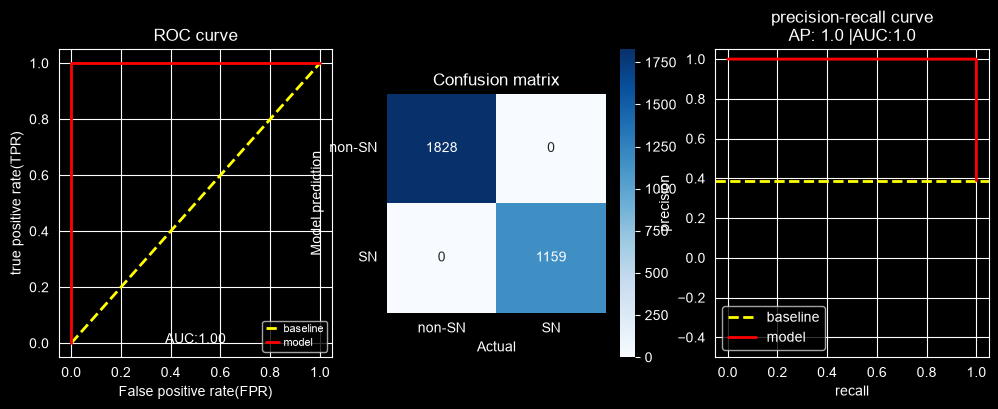

In [33]:
classification_evaluation_plots(y_train,rf_grid_preds,rf_grid_preds_proba)

In [34]:
test_rf_grid_preds=grid_rf.predict(X_test)
test_rf_grid_preds_proba=grid_rf.predict_proba(X_test)[:,1]

In [35]:
classification_reports(y_test,test_rf_grid_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.856195,0.762712,0.819277,0.809453,0.819903
recall,0.846827,0.775862,0.819277,0.811345,0.819277
f1-score,0.851485,0.769231,0.819277,0.810358,0.819552
support,457.000000,290.000000,0.819277,747.000000,747.000000


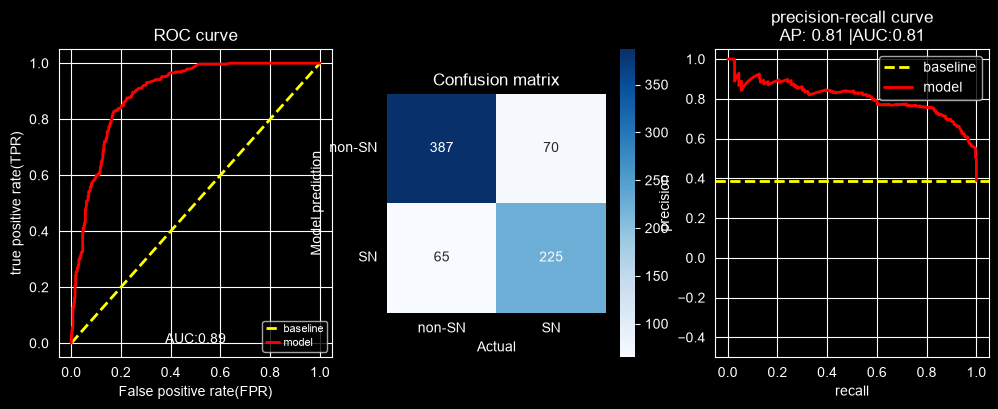

In [36]:
classification_evaluation_plots(y_test,test_rf_grid_preds,test_rf_grid_preds_proba)

In [37]:
search_space3={'lr__C':[0.001, 0.01, 0.1, 1, 10, 100]}
lr_p_grid=GridSearchCV(pipeline,search_space3,scoring='f1_macro',cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=8,random_state=0)).fit(X_train,y_train)

In [38]:
lr_p_grid.best_params_

{'lr__C': 100}

In [39]:
lr_p_grid.best_score_

np.float64(0.7951010721842265)

In [49]:
train_lr_p_grid_preds=lr_p_grid.predict(X_train)
train_lr_p_grid_preds_proba=lr_p_grid.predict_proba(X_train)[:,1]
cohen_kappa_score(y_train,train_lr_p_grid_preds)

0.6326738083408177

In [41]:
classification_reports(y_train,train_lr_p_grid_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.857299,0.775475,0.825578,0.816387,0.825550
recall,0.857768,0.774806,0.825578,0.816287,0.825578
f1-score,0.857533,0.775140,0.825578,0.816337,0.825564
support,1828.000000,1159.000000,0.825578,2987.000000,2987.000000


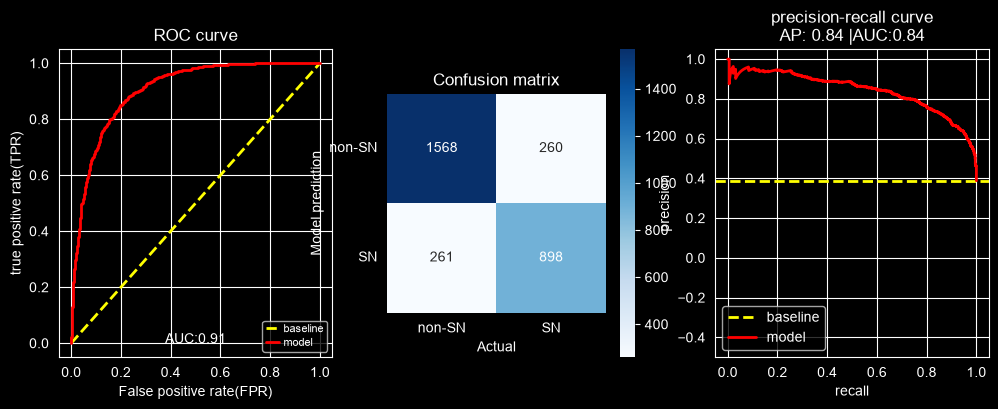

In [42]:
classification_evaluation_plots(y_train,train_lr_p_grid_preds,train_lr_p_grid_preds_proba)

In [43]:
test_lr_p_grid_preds=lr_p_grid.predict(X_test)
test_lr_p_grid_preds_proba=lr_p_grid.predict_proba(X_test)[:,1]

In [44]:
classification_reports(y_test,test_lr_p_grid_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.836245,0.743945,0.800535,0.790095,0.800412
recall,0.838074,0.741379,0.800535,0.789727,0.800535
f1-score,0.837158,0.742660,0.800535,0.789909,0.800472
support,457.000000,290.000000,0.800535,747.000000,747.000000


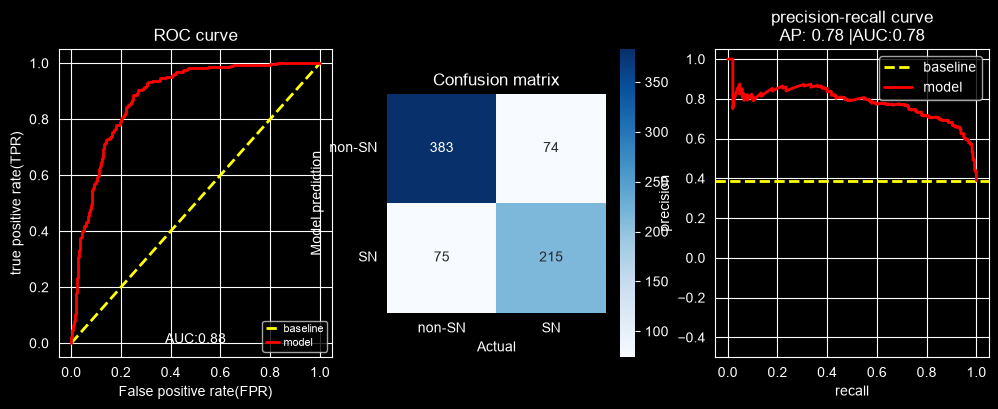

In [45]:
classification_evaluation_plots(y_test,test_lr_p_grid_preds,test_lr_p_grid_preds_proba)

In [46]:
cohen_kappa_score(y_test,test_lr_p_grid_preds)

0.5798190212651901

In [47]:
nf=random_forest().fit(X_train,y_train)
test_nf=nf.predict(X_test)
cohen_kappa_score(y_test,test_nf)

0.601818345620805

In [48]:
cohen_kappa_score(test_lr_p_grid_preds,test_nf)

0.7166256643317246